<a href="https://colab.research.google.com/github/Najwaalya/PCVK_Ganjil_2025/blob/main/Modul7_FilterSpasial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Langkah 1 — Persiapan

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Langkah 2 — Load dan ubah citra ke grayscale

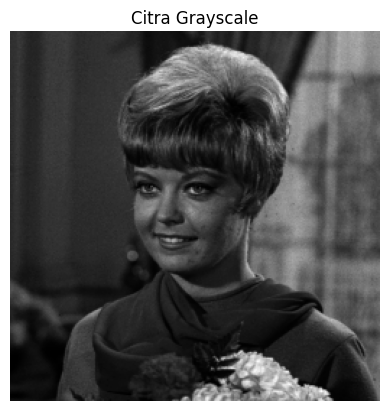

In [22]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('Citra Grayscale')
plt.axis('off')
plt.show()

## Langkah 3 — Buat fungsi konvolusi sendiri

In [23]:
def konvolusi(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    # padding citra agar tidak error di tepi
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image)

    # proses konvolusi
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+k_h, j:j+k_w]
            value = np.sum(region * kernel)
            output[i, j] = np.clip(value, 0, 255)
    return output

## Langkah 4 — Tentukan kernel (filter)

In [24]:
# Sharpening
sharpen = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])

# Average filter
average = np.ones((3,3)) / 9

# Low Pass
lowpass = np.array([[1, 1, 1],
                    [1, 4, 1],
                    [1, 1, 1]]) / 12

# High Pass
highpass = np.array([[-1, 0, 1],
                     [-1, 0, 3],
                     [-3, 0, 1]])

# Emboss
emboss = np.array([[-2, -1, 0],
                   [-1, 1, 1],
                   [0, 1, 2]])

# Sobel kiri (edge detection)
sobel = np.array([[1, 0, -1],
                  [2, 0, -2],
                  [1, 0, -1]])

# Prewitt edge detection
prewitt = np.array([[1, 0, -1],
                    [1, 0, -1],
                    [1, 0, -1]])

## Langkah 5 — Terapkan filter dan tampilkan hasil

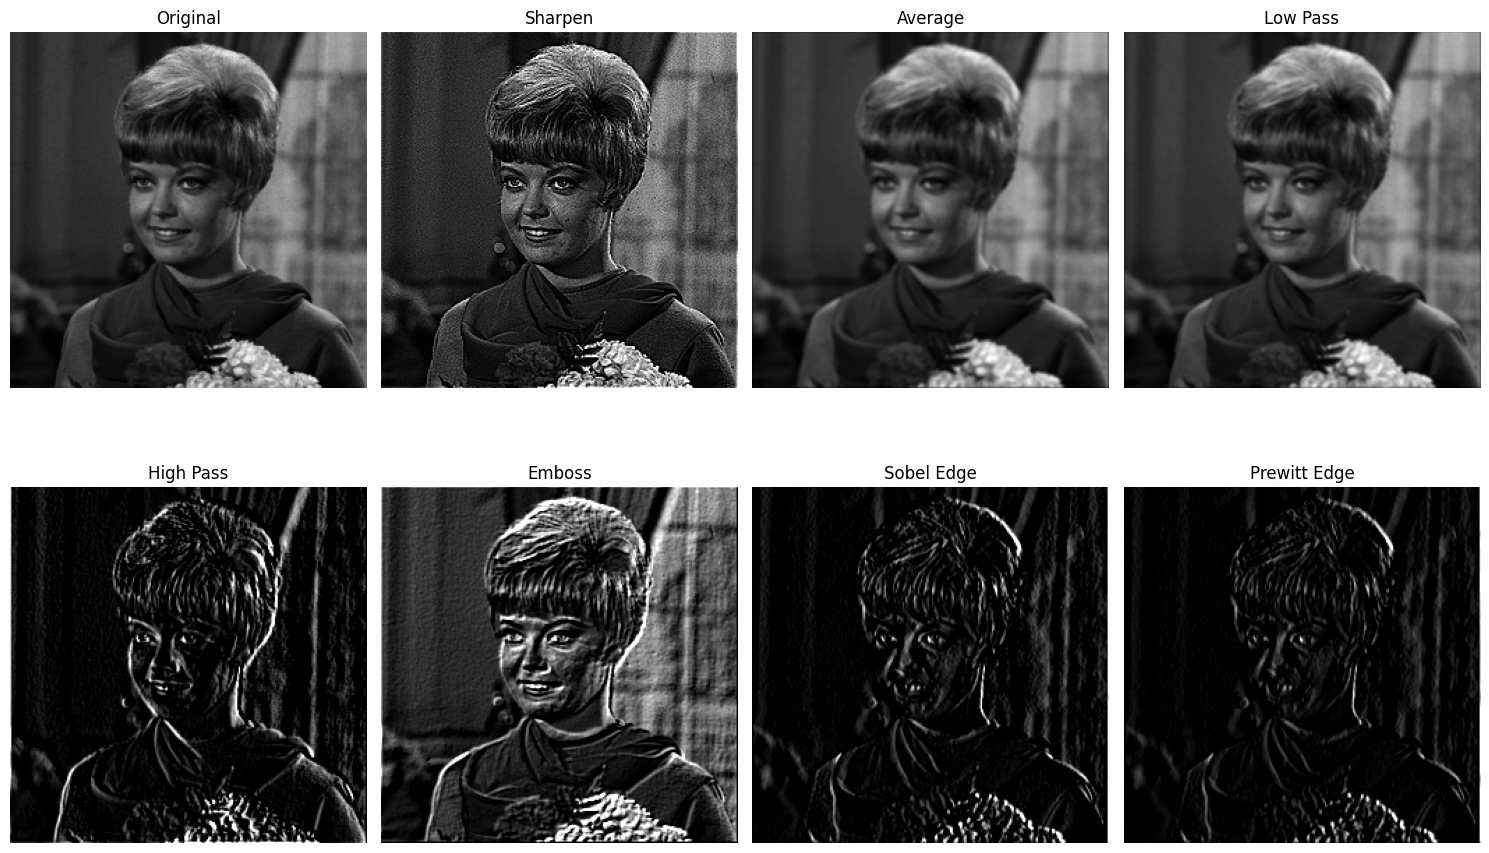

In [25]:
# === Terapkan filter satu per satu ===
filters = {
    "Original": gray,
    "Sharpen": konvolusi(gray, sharpen),
    "Average": konvolusi(gray, average),
    "Low Pass": konvolusi(gray, lowpass),
    "High Pass": konvolusi(gray, highpass),
    "Emboss": konvolusi(gray, emboss),
    "Sobel Edge": konvolusi(gray, sobel),
    "Prewitt Edge": konvolusi(gray, prewitt)
}

# === Tampilkan semua hasil ===
plt.figure(figsize=(15,10))
for i, (name, result) in enumerate(filters.items()):
    plt.subplot(2,4,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Langkah 6 — Gaussian Blur (menggunakan kernel dari kode modul)

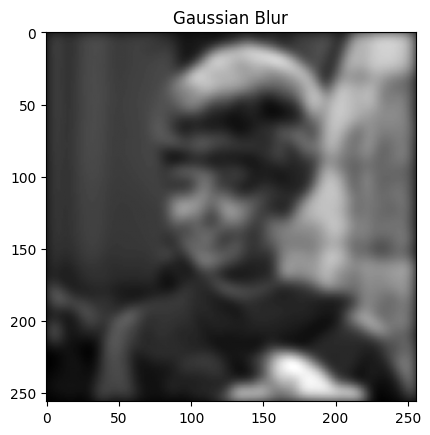

In [26]:
import math
kernel_size = 21  # bisa juga 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T

gaussian_blur = konvolusi(gray, gauss_kernel)
plt.imshow(gaussian_blur, cmap='gray')
plt.title('Gaussian Blur')
plt.show()